In [1]:
%run ../../../setup_workspace.py # ../ means level up 
pi = np.pi
import scipy
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from matplotlib.ticker import ScalarFormatter
import ipywidgets as widgets
from ipywidgets import interact, IntSlider

In [17]:
x = [1,2,3,4,5]
y = [2,6,4,3,4]

x = np.array(x)
x


array([1, 2, 3, 4, 5])

# SC5732

In [2]:
Exp = BM26_experiment(r'F:\SC_5732\RAW_DATA\LL_samples\LL_samples_LL_202_020')

plt.plot(Exp.get_Tr_profile())

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'F:\\SC_5732\\RAW_DATA\\LL_samples\\LL_samples_LL_202_020\\SAXS'

In [ ]:
SAXS_poni = r"F:\SC_5732\RAW_DATA\SAXS_12p8keV_2m_SAXS-WAXS_LDSC.poni"
WAXS_poni = r"F:\SC_5732\RAW_DATA\WAXS_12p8keV_2m_SAXS-WAXS_LDSC.poni"
ai_SAXS = pyFAI.load(SAXS_poni)
ai_WAXS = pyFAI.load(WAXS_poni)

In [ ]:
# Mask file 
mask = r"F:\SC_5732\RAW_DATA\MASK_SAXS_2m_AgBh.edf"
file_mask = mask
img_mask_SAXS = fabio.open(file_mask).data

# Mask file 
mask = r"F:\SC_5732\RAW_DATA\MASK_WAXS_2m_LaB6.edf"
file_mask = mask
img_mask_WAXS = fabio.open(file_mask).data

In [ ]:
def average(I):
    res = np.zeros(len(I[0]))
    for i in range(len(I)):
        res += I[i]

    res /= len(I)
    return res

In [ ]:
Exp = BM26_experiment(r'F:\SC_5732\RAW_DATA\LL_samples\LL_samples_LL_202_020')

plt.plot(Exp.get_Tr_profile())

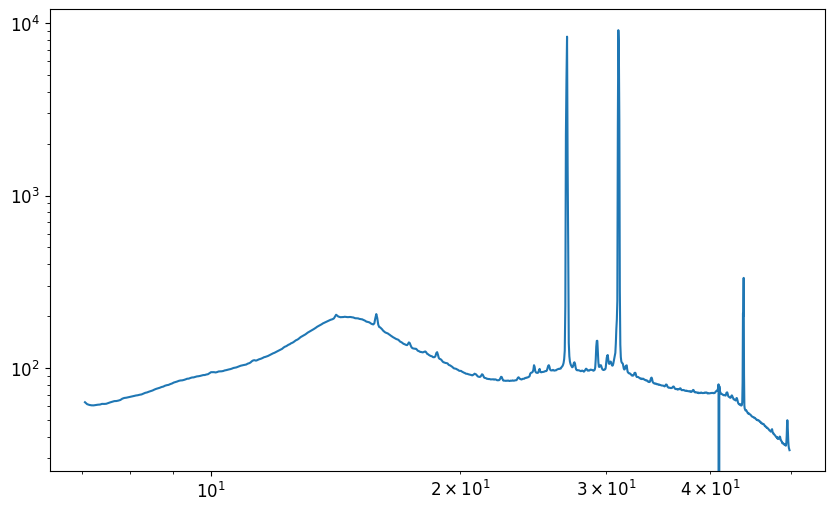

In [71]:
q, I_array = Exp.integrate1d_WAXS(ai_WAXS, 1000, mask=img_mask_WAXS, unit='q_nm^-1')
I = average(I_array)
plt.semilogx()
plt.semilogy()

plt.plot(q, I)

In [72]:
df = pd.DataFrame({'q': q, 'I':I})

df.to_csv(r'F:\SC_5732\RAW_DATA\LL_samples\Integrated\LL_202_WAXS.txt', sep=str('\t'), index=False)

# SC5782

Found 116 EDF files in SAXS


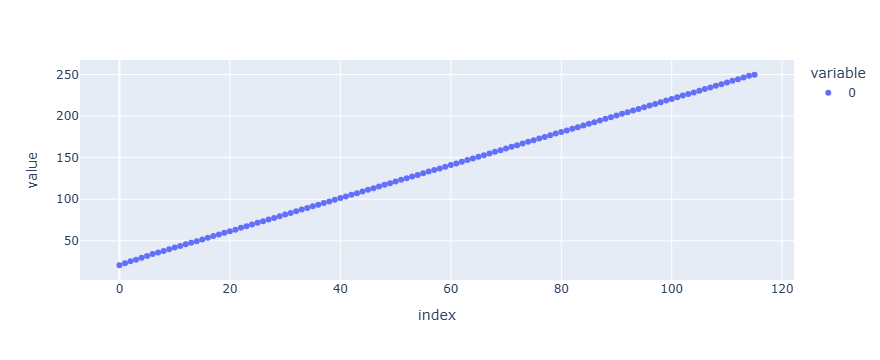

In [8]:
Exp = BM26_experiment(r'\\Synology\Data\2026\SC5781\RAW_DATA\LL_samples\LL_samples_LL241_Heating_250C')

T_241_heat = Exp.get_T_profile()
px.scatter(T_241_heat)

In [16]:
I

array([0., 0., 0., ..., 0., 0., 0.], shape=(2000,))

In [30]:
Exp = BM26_experiment(r'\\Synology\Data\2026\SC5781\RAW_DATA\LL_samples\LL_samples_LL241_Heating_250C')
I_heat = []
T_241_heat = Exp.get_T_profile()

for i in range(len(T_241_heat)):
    q, I = Exp.get_1d_WAXS(i)
    for k in range(2000):
        I_heat.append(I[k])

Found 116 EDF files in SAXS


In [31]:
Exp = BM26_experiment(r'\\Synology\Data\2026\SC5781\RAW_DATA\LL_samples\LL_samples_LL241_Cooling_250C_20C')
I_cool = []
T_241_cool = Exp.get_T_profile()

for i in range(len(T_241_cool)):
    q, I = Exp.get_1d_WAXS(i)
    for k in range(2000):
        I_cool.append(I[k])

Found 116 EDF files in SAXS


In [25]:
pd.DataFrame(T_241_heat).to_csv(r'C:\Users\LabPCA\Desktop\LL_Samples\T_241_heat.txt', sep='\t', index=False)

In [26]:
pd.DataFrame(T_241_cool).to_csv(r'C:\Users\LabPCA\Desktop\LL_Samples\T_241_cool.txt', sep='\t', index=False)


In [32]:
pd.DataFrame(I_heat).to_csv(r'C:\Users\LabPCA\Desktop\LL_Samples\I_241_heat_WAXS.txt', sep='\t', index=False)


In [33]:
pd.DataFrame(I_cool).to_csv(r'C:\Users\LabPCA\Desktop\LL_Samples\I_241_cool_WAXS.txt', sep='\t', index=False)


In [34]:
pd.DataFrame(q).to_csv(r'C:\Users\LabPCA\Desktop\LL_Samples\q_241_WAXS.txt', sep='\t', index=False)

